<a href="https://colab.research.google.com/github/aronbarbosag/linguagens-de-programacao/blob/main/atividade_1_lp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Perguntas

1.  Qual Canal gera mais receita? e lucro ? R: Loja Física e Loja Física
2.  Quais UFs concentram a operação ? R: SC maior numero de vendas
3.  Qual a sazonalidade das vendas ? 2023- alta em julho - queda em agosto, 2024 alta em novembro
4.  Quais produtos são os campeos de margem : Top 5: Produto_60 ,Produto_111,Produto_58,Produto_55,Produto_102


### Montando drive


In [30]:
caminho_df = "../datasets/vendas_brasil.csv"


In [31]:
df_vendas_brasil = pd.read_csv(caminho_df, parse_dates=["data"])


In [32]:
df_vendas_brasil.head()


,data,uf,canal,categoria,segmento,produto,quantidade,receita,custo,lucro
0,2023-01-01 00:00:00.000000000,BA,Online,Acessórios,Corporativo,Produto_40,1,2133.016905,1515.430447,617.586458
1,2023-01-01 07:00:38.895558223,BA,Loja Física,Acessórios,Corporativo,Produto_27,13,18812.079172,15735.396787,3076.682385
2,2023-01-01 07:00:38.895558223,BA,Online,Eletrônicos,Distribuidor,Produto_108,1,666.417476,483.318288,183.099188
3,2023-01-01 14:01:17.791116446,PR,Online,Informática,Corporativo,Produto_51,9,6616.534025,5587.961806,1028.572218
4,2023-01-02 18:03:53.373349339,MG,Marketplace,Informática,Corporativo,Produto_3,2,4544.174036,2797.938769,1746.235267


In [33]:
df_vendas_brasil.info()


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        2500 non-null   datetime64[ns]
 1   uf          2500 non-null   str           
 2   canal       2500 non-null   str           
 3   categoria   2500 non-null   str           
 4   segmento    2500 non-null   str           
 5   produto     2500 non-null   str           
 6   quantidade  2500 non-null   int64         
 7   receita     2500 non-null   float64       
 8   custo       2500 non-null   float64       
 9   lucro       2500 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), str(5)
memory usage: 195.4 KB


In [34]:
df_vendas_brasil.describe(include="str").T


,count,unique,top,freq
uf,2500,8,SC,344
canal,2500,4,Loja Física,685
categoria,2500,5,Eletrônicos,550
segmento,2500,3,Varejo,850
produto,2500,119,Produto_62,37


In [35]:
df_vendas_brasil.describe().T


,count,mean,min,25%,50%,75%,max,std
data,2500,2024-01-08 15:33:34.859063552,2023-01-01 00:00:00,2023-07-08 01:12:19.015606016,2024-01-12 12:55:36.374549760,2024-07-12 19:40:07.202881024,2024-12-30 09:58:42.208883552,NaN
quantidade,2500.0,7.4548,1.0,4.0,7.0,11.0,14.0,3.998994
receita,2500.0,9378.973313,63.874351,3143.639426,7279.178892,13861.552466,34915.904004,7716.733689
custo,2500.0,6582.3228,39.260095,2172.26814,4965.790355,9687.216493,27914.303362,5547.908951
lucro,2500.0,2796.650513,24.614257,854.349226,2062.553868,4066.45586,13787.427851,2492.585402


## EDA


#### Análise univariada


In [36]:
cat_cols = df_vendas_brasil.select_dtypes("str").columns.delete(-1)
cat_cols


Index(['uf', 'canal', 'categoria', 'segmento'], dtype='str')

In [37]:
def eval_cat_col(col: pd.Series):

    print(col.unique())
    print()
    print(col.value_counts().sort_values(ascending=False))
    print()


In [38]:
for col in cat_cols:
    print(f"Coluna: {col.upper()}")
    eval_cat_col(df_vendas_brasil[col])


Coluna: UF
<StringArray>
['BA', 'PR', 'MG', 'SP', 'ES', 'RS', 'SC', 'RJ']
Length: 8, dtype: str

uf
SC    344
RS    320
ES    318
PR    316
MG    316
BA    307
SP    296
RJ    283
Name: count, dtype: int64

Coluna: CANAL
<StringArray>
['Online', 'Loja Física', 'Marketplace', 'Representante']
Length: 4, dtype: str

canal
Loja Física      685
Online           632
Marketplace      593
Representante    590
Name: count, dtype: int64

Coluna: CATEGORIA
<StringArray>
['Acessórios', 'Eletrônicos', 'Informática', 'Móveis', 'Serviços']
Length: 5, dtype: str

categoria
Eletrônicos    550
Móveis         502
Serviços       489
Informática    488
Acessórios     471
Name: count, dtype: int64

Coluna: SEGMENTO
<StringArray>
['Corporativo', 'Distribuidor', 'Varejo']
Length: 3, dtype: str

segmento
Varejo          850
Corporativo     825
Distribuidor    825
Name: count, dtype: int64



In [39]:
df_vendas_brasil_gb_canal_receita = (
    df_vendas_brasil.groupby("canal")["receita"].sum().sort_values(ascending=False)
)
df_vendas_brasil_gb_canal_receita


canal
Loja Física      6.527691e+06
Online           6.091973e+06
Marketplace      5.729897e+06
Representante    5.097873e+06
Name: receita, dtype: float64

In [40]:
sns.set_palette("crest")


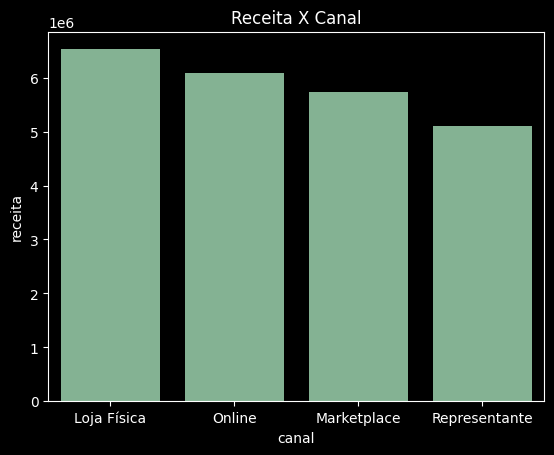

In [41]:
plt.title("Receita X Canal")
sns.barplot(data=df_vendas_brasil_gb_canal_receita);


In [42]:
df_vendas_brasil_gb_canal_lucro = (
    df_vendas_brasil.groupby("canal")["lucro"].sum().sort_values(ascending=False)
)
df_vendas_brasil_gb_canal_lucro


canal
Loja Física      1.915974e+06
Online           1.835425e+06
Marketplace      1.698461e+06
Representante    1.541766e+06
Name: lucro, dtype: float64

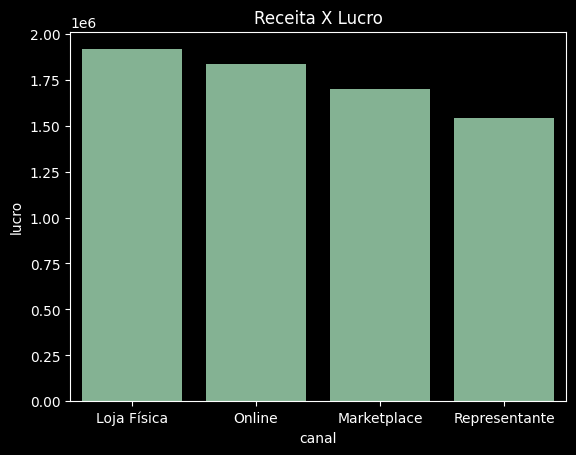

In [43]:
plt.title("Receita X Lucro")
sns.barplot(data=df_vendas_brasil_gb_canal_lucro);


Loja Física maior receita sendo 6.5 milhoes e tambem maior lucro sendo 1.9 milhoes


Qual canal gerou maior custo beneficio ?
Percentagem Lucro sobre Custo ?


In [44]:
df_vendas_brasil["rel_lucro_custo"] = (
    df_vendas_brasil["lucro"] / df_vendas_brasil["custo"]
) * 100


In [45]:
df_vendas_brasil_gb_canal_rel_lucro_custo = (
    df_vendas_brasil.groupby("canal")["rel_lucro_custo"]
    .mean()
    .sort_values(ascending=False)
)
df_vendas_brasil_gb_canal_rel_lucro_custo


canal
Online           45.820984
Representante    45.111354
Marketplace      44.822667
Loja Física      44.759107
Name: rel_lucro_custo, dtype: float64

<Axes: xlabel='rel_lucro_custo', ylabel='canal'>

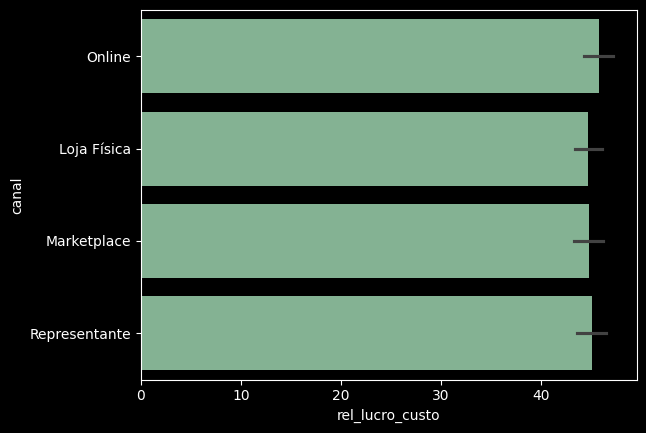

In [46]:
sns.barplot(data=df_vendas_brasil, y="canal", x="rel_lucro_custo", estimator="mean")


Loja Online em média tem a relação custo e lucro mais vantajosa.


In [47]:
df_vendas_gb_produto = (
    df_vendas_brasil.groupby("produto", as_index=False)["rel_lucro_custo"]
    .mean()
    .sort_values(by="rel_lucro_custo", ascending=False)
)
top_10_produtos_campeos_em_margem = df_vendas_gb_produto.head(10)


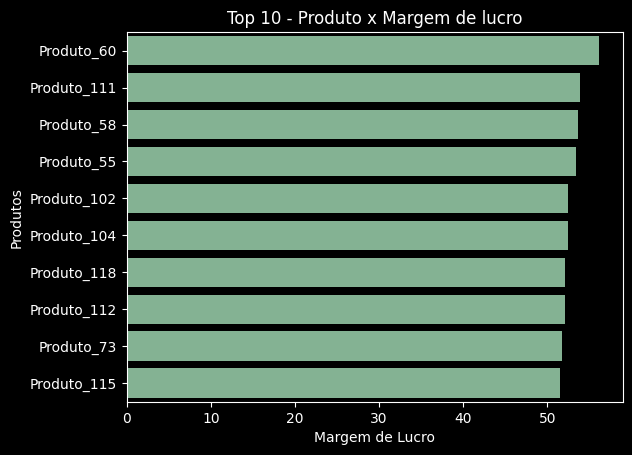

In [48]:
plt.title("Top 10 - Produto x Margem de lucro")
plt.xlabel("Margem de Lucro")
plt.ylabel("Produtos")
sns.barplot(data=top_10_produtos_campeos_em_margem, y="produto", x="rel_lucro_custo")
plt.show()


In [49]:
df_vendas_brasil["data"].describe()


count                             2500
mean     2024-01-08 15:33:34.859063552
min                2023-01-01 00:00:00
25%      2023-07-08 01:12:19.015606016
50%      2024-01-12 12:55:36.374549760
75%      2024-07-12 19:40:07.202881024
max      2024-12-30 09:58:42.208883552
Name: data, dtype: object

In [50]:
df_vendas_brasil["mes"] = df_vendas_brasil["data"].dt.month_name()


In [51]:
df_vendas_brasil["mes_curto"] = df_vendas_brasil["mes"].apply(lambda col: col[:3])


In [52]:
df_vendas_brasil["mes_curto"].unique()


<StringArray>
['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov',
 'Dec']
Length: 12, dtype: str

##### Filtrando ano 2023


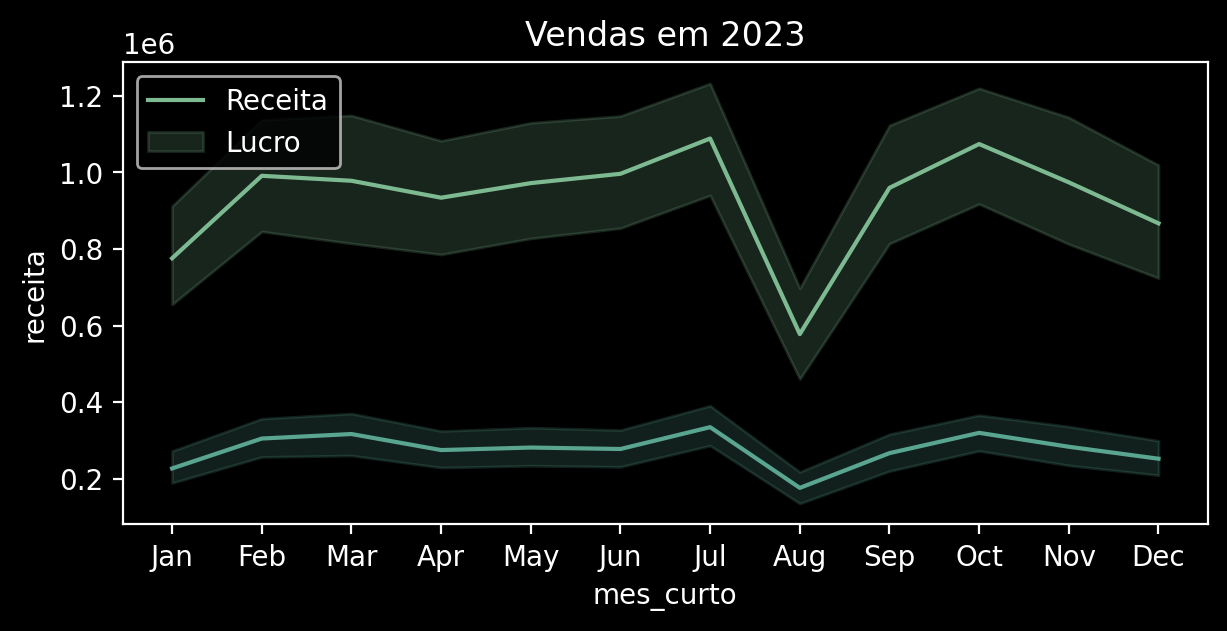

In [53]:
df_vendas_brasil_2023 = df_vendas_brasil[df_vendas_brasil["data"].dt.year == 2023]
plt.figure(figsize=(7, 3), dpi=200)
plt.title("Vendas em 2023")
sns.lineplot(data=df_vendas_brasil_2023, x="mes_curto", y="receita", estimator="sum")
sns.lineplot(data=df_vendas_brasil_2023, x="mes_curto", y="lucro", estimator="sum")

plt.legend(["Receita", "Lucro"])


Mês de agosto apresenta uma queda significativa na receita e no lucro enquanto um mês antes julho tem a maior alta na receita.


<Axes: title={'center': 'Quantidade de Vendas em 2023'}, xlabel='count', ylabel='mes_curto'>

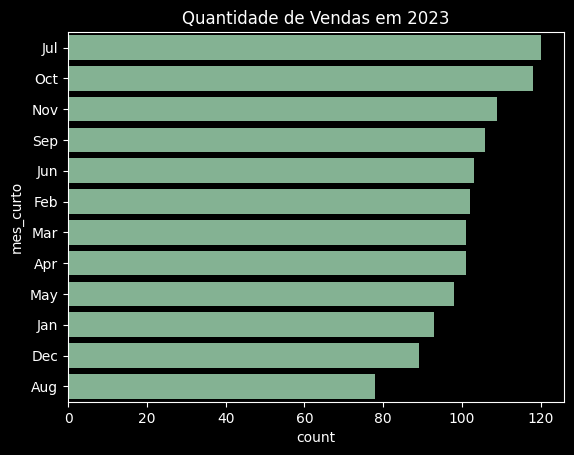

In [54]:
plt.title("Quantidade de Vendas em 2023")
sns.barplot(
    df_vendas_brasil_2023["mes_curto"].value_counts(ascending=False), orient="h"
)


Mês de julho foi o que mais teve vendas em quantidade


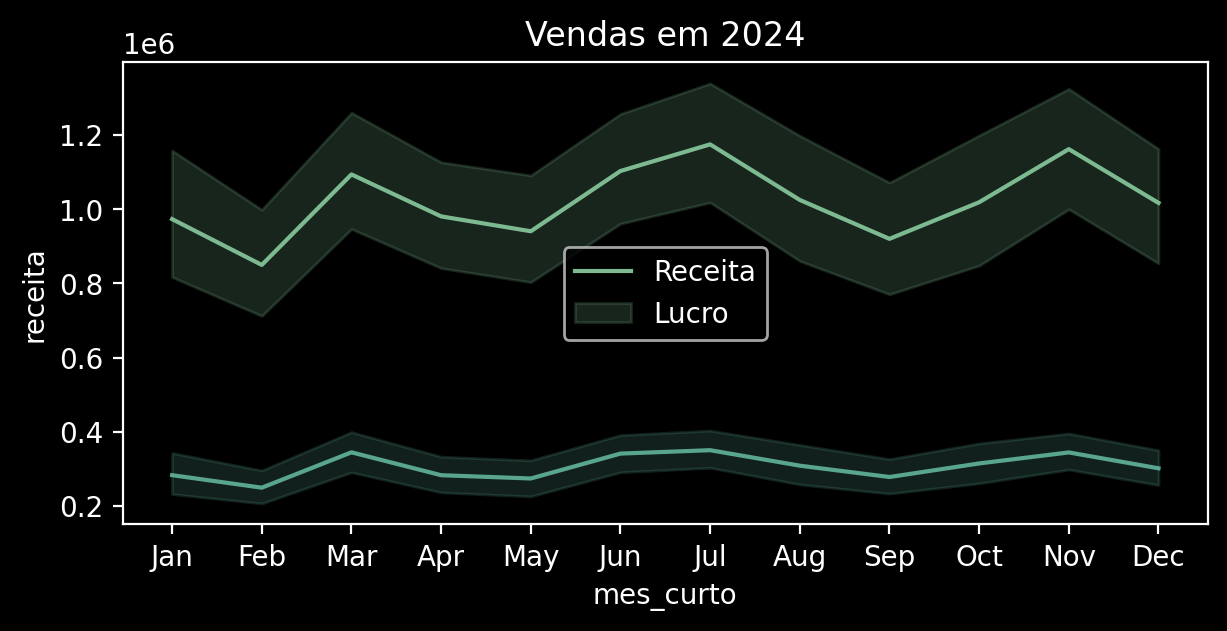

In [55]:
df_vendas_brasil_2024 = df_vendas_brasil[df_vendas_brasil["data"].dt.year == 2024]
plt.figure(figsize=(7, 3), dpi=200)
plt.title("Vendas em 2024")
sns.lineplot(data=df_vendas_brasil_2024, x="mes_curto", y="receita", estimator="sum")
sns.lineplot(data=df_vendas_brasil_2024, x="mes_curto", y="lucro", estimator="sum")

plt.legend(["Receita", "Lucro"])


Em 2024 não há uma queda signficativa na receita em comparação com o ano de 2023
O pico de receita continua sendo julho e o menor valor em fevereiro, porém nao muito significante


<Axes: title={'center': 'Quantidade de Vendas em 2024'}, xlabel='count', ylabel='mes_curto'>

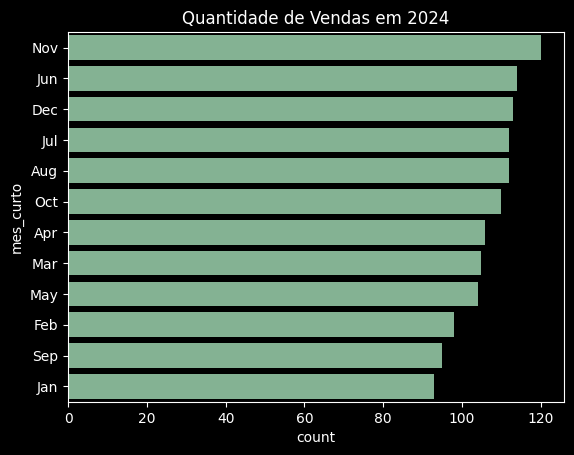

In [56]:
plt.title("Quantidade de Vendas em 2024")
sns.barplot(
    df_vendas_brasil_2024["mes_curto"].value_counts(ascending=False), orient="h"
)


Em 2024 o pico de quantidade de vendas foi em Novembro, e a quebda foi em janeiro
